In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Image, display

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.3f}".format)

In [138]:
df = pd.read_csv(
    "data/raw/db_homicidios_sp_onu.csv",
    delimiter=";"
)

df.head()

,codigo,municipio,homicide_count,per_cent_urban,resident_population,infant_mortality,per_cent_male,per_cent_youth,per_cent_unemployed,gdp_per_capita,gini
0,3500105,Adamantina,9.000,"96,68",34687,"10,5","48,16","18,29","56,41","38997,12","0,5151"
1,3500204,Adolfo,3.000,"92,05",4351,NaN,"49,48","18,69","72,31","32578,28","0,4111"
2,3500303,Aguaí,7.000,"93,21",32072,"8,11","49,51","21,67","71,32","35551,7","0,4804"
3,3500402,Águas da Prata,2.000,"87,65",7369,"14,49","47,98","15,9","76,88","25297,02","0,5305"
4,3500501,Águas de Lindóia,2.000,"87,16",17930,"4,69","48,64","18,16","60,91","30971,23","0,4612"


In [79]:
df[variaveis].describe()

,homicide_count,resident_population
count,555.000,645.000
mean,18.173,68854.633
std,77.641,464421.001
min,1.000,907.000
25%,2.000,5466.000
50%,5.000,13163.000
75%,12.500,38324.000
max,1713.000,11451999.000


In [80]:
df.isnull().sum()

codigo                   0
municipio                0
homicide_count          90
per_cent_urban           0
resident_population      0
infant_mortality       196
per_cent_male            0
per_cent_youth           0
per_cent_unemployed      0
gdp_per_capita           0
gini                     0
dtype: int64

In [139]:
variaveis = [
    "homicide_count",
    "per_cent_urban",
    "resident_population",
    "infant_mortality",
    "per_cent_male",
    "per_cent_youth",
    "per_cent_unemployed",
    "gdp_per_capita",
    "gini"
]

for col in variaveis:
    df[col] = (
        df[col]
        .astype(str)
        .str.replace(",", ".", regex=False)
        .str.strip()
    )
    df[col] = pd.to_numeric(df[col], errors="coerce")

In [140]:
df[variaveis].describe()

,homicide_count,per_cent_urban,resident_population,infant_mortality,per_cent_male,per_cent_youth,per_cent_unemployed,gdp_per_capita,gini
count,555.000,645.000,645.000,449.000,645.000,645.000,645.000,645.000,645.000
mean,18.173,86.532,68854.633,16.031,49.926,20.299,66.584,42570.214,0.459
std,77.641,12.989,464421.001,11.187,2.867,2.219,12.716,39799.762,0.057
min,1.000,27.040,907.000,2.000,45.320,14.350,-35.610,9468.330,0.334
25%,2.000,81.780,5466.000,9.390,48.800,19.090,61.290,23966.140,0.418
50%,5.000,90.550,13163.000,12.610,49.510,20.240,68.630,32233.410,0.456
75%,12.500,96.050,38324.000,19.010,50.160,21.450,74.300,46763.190,0.495
max,1713.000,100.000,11451999.000,68.970,81.610,37.390,92.070,457517.700,0.686


In [84]:
df_tratado = df.copy()

In [136]:
variaveis = [
    "homicide_count",
    "per_cent_urban",
    "resident_population",
    "infant_mortality",
    "per_cent_male",
    "per_cent_youth",
    "per_cent_unemployed",
    "gdp_per_capita",
    "gini"
]

for col in variaveis:
    df_tratado[col] = (
        df_tratado[col]
        .astype(str)
        .str.replace(",", ".", regex=False)
        .str.strip()
    )
    df_tratado[col] = pd.to_numeric(df_tratado[col], errors="coerce")

In [86]:
df_tratado[variaveis].describe()

,homicide_count,per_cent_urban,resident_population,infant_mortality,per_cent_male,per_cent_youth,per_cent_unemployed,gdp_per_capita,gini
count,555.000,645.000,645.000,449.000,645.000,645.000,645.000,645.000,645.000
mean,18.173,86.532,68854.633,16.031,49.926,20.299,66.584,42570.214,0.459
std,77.641,12.989,464421.001,11.187,2.867,2.219,12.716,39799.762,0.057
min,1.000,27.040,907.000,2.000,45.320,14.350,-35.610,9468.330,0.334
25%,2.000,81.780,5466.000,9.390,48.800,19.090,61.290,23966.140,0.418
50%,5.000,90.550,13163.000,12.610,49.510,20.240,68.630,32233.410,0.456
75%,12.500,96.050,38324.000,19.010,50.160,21.450,74.300,46763.190,0.495
max,1713.000,100.000,11451999.000,68.970,81.610,37.390,92.070,457517.700,0.686


In [134]:
##Tratamentos
##homicidios - substituir nulos por zero | significa ausência de registro de homícidios no período
df_tratado["homicide_count"] = df_tratado["homicide_count"].fillna(0)

##mortalidade infantil - imputação pela mediana: motivos robusta a outliers, mantém todos municípios e comum em estudos socioeconômicos
df_tratado["infant_mortality"] = pd.to_numeric(
    df_tratado["infant_mortality"], errors="coerce"
)

# imputação pela mediana
df_tratado["infant_mortality"] = df_tratado["infant_mortality"].fillna(
    df_tratado["infant_mortality"].median()
)

##taxa de desemprego - Se o desemprego calculado for negativo: unemployment=max(0,unemployment)
df_tratado["per_cent_unemployed"] = df["per_cent_unemployed"].clip(lower=0)

In [88]:
df_tratado.isnull().sum()

codigo                 0
municipio              0
homicide_count         0
per_cent_urban         0
resident_population    0
infant_mortality       0
per_cent_male          0
per_cent_youth         0
per_cent_unemployed    0
gdp_per_capita         0
gini                   0
dtype: int64

In [118]:
variaveis = [
    "homicide_count",
    "per_cent_urban",
    "resident_population",
    "infant_mortality",
    "per_cent_male",
    "per_cent_youth",
    "per_cent_unemployed",
    "gdp_per_capita",
    "gini"
]

desc = df_tratado[variaveis].describe()

desc

,homicide_count,per_cent_urban,resident_population,infant_mortality,per_cent_male,per_cent_youth,per_cent_unemployed,gdp_per_capita,gini
count,645.000,645.000,645.000,645.000,645.000,645.000,645.000,645.000,645.000
mean,15.637,86.532,68854.633,14.991,49.926,20.299,66.679,42570.214,0.459
std,72.287,12.989,464421.001,9.463,2.867,2.219,12.085,39799.762,0.057
min,0.000,27.040,907.000,2.000,45.320,14.350,0.000,9468.330,0.334
25%,1.000,81.780,5466.000,10.470,48.800,19.090,61.290,23966.140,0.418
50%,4.000,90.550,13163.000,12.610,49.510,20.240,68.630,32233.410,0.456
75%,11.000,96.050,38324.000,14.620,50.160,21.450,74.300,46763.190,0.495
max,1713.000,100.000,11451999.000,68.970,81.610,37.390,92.070,457517.700,0.686


In [127]:
##Estatística Descritiva
df_tratado[variaveis].describe()

,homicide_count,tx_homicidios_observada,tx_homicidios_bayes,per_cent_urban,resident_population,infant_mortality,per_cent_male,per_cent_youth,per_cent_unemployed,gdp_per_capita,gini
count,645.000,645.000,645.000,645.000,645.000,645.000,645.000,645.000,645.000,645.000,645.000
mean,15.637,29.209,23.999,86.532,68854.633,14.991,49.926,20.299,66.679,42570.214,0.459
std,72.287,22.895,4.501,12.989,464421.001,9.463,2.867,2.219,12.085,39799.762,0.057
min,0.000,0.000,11.785,27.040,907.000,2.000,45.320,14.350,0.000,9468.330,0.334
25%,1.000,15.273,21.683,81.780,5466.000,10.470,48.800,19.090,61.290,23966.140,0.418
50%,4.000,25.468,23.201,90.550,13163.000,12.610,49.510,20.240,68.630,32233.410,0.456
75%,11.000,38.986,25.457,96.050,38324.000,14.620,50.160,21.450,74.300,46763.190,0.495
max,1713.000,167.224,60.242,100.000,11451999.000,68.970,81.610,37.390,92.070,457517.700,0.686


In [137]:
comparacao = pd.DataFrame({

    "missing_original": df[variaveis].isnull().sum(),

    "missing_tratado": df_tratado[variaveis].isnull().sum(),

    "media_original": df[variaveis].mean(),

    "media_tratado": df_tratado[variaveis].mean()

})

comparacao = comparacao.round(3)

comparacao

,missing_original,missing_tratado,media_original,media_tratado
homicide_count,90,0,18.173,15.637
per_cent_urban,0,0,86.532,86.532
resident_population,0,0,68854.633,68854.633
infant_mortality,196,0,16.031,14.991
per_cent_male,0,0,49.926,49.926
per_cent_youth,0,0,20.299,20.299
per_cent_unemployed,0,0,66.679,66.679
gdp_per_capita,0,0,42570.214,42570.214
gini,0,0,0.459,0.459


In [62]:
comparacao.to_excel(
    "outputs/tables/comparacao_base_original_tratada.xlsx"
)

In [105]:
tx_homicidios_observada = (
    df_tratado["homicide_count"] /
    df_tratado["resident_population"]
) * 100000

In [129]:
# taxa observada
tx_homicidios_observada = (
    df_tratado["homicide_count"] /
    df_tratado["resident_population"]
) * 100000

df_tratado["tx_homicidios_observada"] = (
    df_tratado["homicide_count"] /
    df_tratado["resident_population"]
) * 100000

# taxa média estadual
taxa_media = (
    df_tratado["homicide_count"].sum() /
    df_tratado["resident_population"].sum()
) * 100000


# constante de suavização
k = df_tratado["resident_population"].mean()


# estimador empírico de Bayes
df_tratado["tx_homicidios_bayes"] = (
    (k * taxa_media) +
    (df_tratado["resident_population"] * tx_homicidios_observada)
) / (k + df_tratado["resident_population"])

In [99]:
##Modelagem
X = df_tratado[variaveis]
y = df_tratado["tx_homicidios_bayes"]

In [132]:
variaveis = [
    "homicide_count",
    "tx_homicidios_observada",
    "tx_homicidios_bayes",
    "per_cent_urban",
    "resident_population",
    "infant_mortality",
    "per_cent_male",
    "per_cent_youth",
    "per_cent_unemployed",
    "gdp_per_capita",
    "gini"
]

In [126]:
df_tratado[variaveis].describe().T.round(3)

,count,mean,std,min,25%,50%,75%,max
homicide_count,645.000,15.637,72.287,0.000,1.000,4.000,11.000,1713.000
tx_homicidios_observada,645.000,29.209,22.895,0.000,15.273,25.468,38.986,167.224
tx_homicidios_bayes,645.000,23.999,4.501,11.785,21.683,23.201,25.457,60.242
per_cent_urban,645.000,86.532,12.989,27.040,81.780,90.550,96.050,100.000
resident_population,645.000,68854.633,464421.001,907.000,5466.000,13163.000,38324.000,11451999.000
infant_mortality,645.000,14.991,9.463,2.000,10.470,12.610,14.620,68.970
per_cent_male,645.000,49.926,2.867,45.320,48.800,49.510,50.160,81.610
per_cent_youth,645.000,20.299,2.219,14.350,19.090,20.240,21.450,37.390
per_cent_unemployed,645.000,66.679,12.085,0.000,61.290,68.630,74.300,92.070
gdp_per_capita,645.000,42570.214,39799.762,9468.330,23966.140,32233.410,46763.190,457517.700


In [33]:
df_tratado[["municipio","tx_homicidios_bayes"]].head()

,municipio,tx_homicidios_bayes
0,Adamantina,23.794
1,Adolfo,25.459
2,Aguaí,22.429
3,Águas da Prata,23.139
4,Águas de Lindóia,20.323


In [36]:
variaveis = [
    "homicide_count",
    "tx_homicidios_observada",
    "tx_homicidios_bayes",
    "per_cent_urban",
    "resident_population",
    "infant_mortality",
    "per_cent_male",
    "per_cent_youth",
    "per_cent_unemployed",
    "gdp_per_capita",
    "gini"
]

In [120]:
##Estatística Descritiva
df_tratado[variaveis].describe()

,homicide_count,per_cent_urban,resident_population,infant_mortality,per_cent_male,per_cent_youth,per_cent_unemployed,gdp_per_capita,gini
count,645.000,645.000,645.000,645.000,645.000,645.000,645.000,645.000,645.000
mean,15.637,86.532,68854.633,14.991,49.926,20.299,66.679,42570.214,0.459
std,72.287,12.989,464421.001,9.463,2.867,2.219,12.085,39799.762,0.057
min,0.000,27.040,907.000,2.000,45.320,14.350,0.000,9468.330,0.334
25%,1.000,81.780,5466.000,10.470,48.800,19.090,61.290,23966.140,0.418
50%,4.000,90.550,13163.000,12.610,49.510,20.240,68.630,32233.410,0.456
75%,11.000,96.050,38324.000,14.620,50.160,21.450,74.300,46763.190,0.495
max,1713.000,100.000,11451999.000,68.970,81.610,37.390,92.070,457517.700,0.686


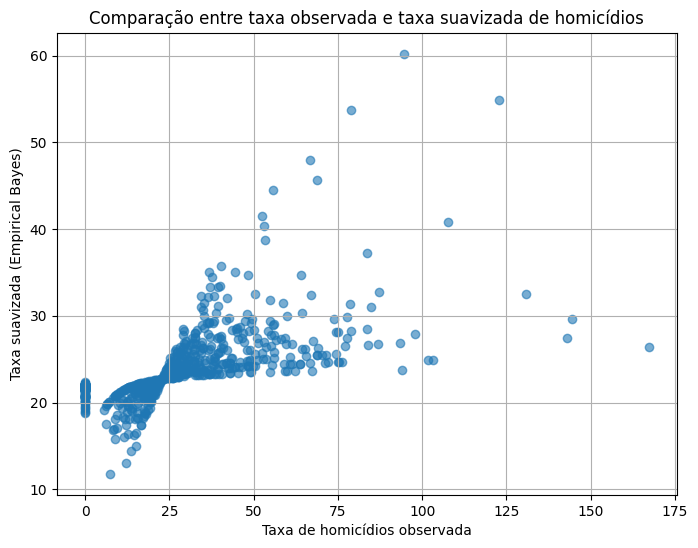

In [53]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(
    df_tratado["tx_homicidios_observada"],
    df_tratado["tx_homicidios_bayes"],
    alpha=0.6
)

plt.xlabel("Taxa de homicídios observada")
plt.ylabel("Taxa suavizada (Empirical Bayes)")

plt.title("Comparação entre taxa observada e taxa suavizada de homicídios")

plt.grid(True)

plt.show()

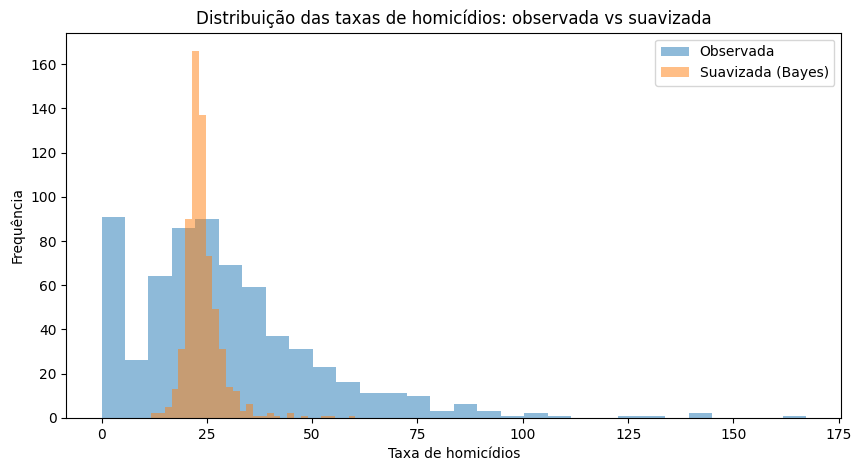

In [54]:
plt.figure(figsize=(10,5))

plt.hist(
    df_tratado["tx_homicidios_observada"],
    bins=30,
    alpha=0.5,
    label="Observada"
)

plt.hist(
    df_tratado["tx_homicidios_bayes"],
    bins=30,
    alpha=0.5,
    label="Suavizada (Bayes)"
)

plt.xlabel("Taxa de homicídios")
plt.ylabel("Frequência")

plt.title("Distribuição das taxas de homicídios: observada vs suavizada")

plt.legend()

plt.show()

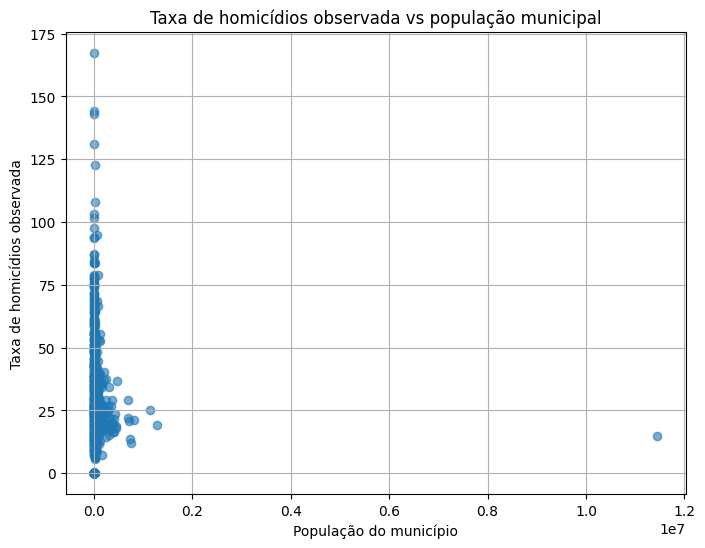

In [55]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(
    df_tratado["resident_population"],
    df_tratado["tx_homicidios_observada"],
    alpha=0.6
)

plt.xlabel("População do município")
plt.ylabel("Taxa de homicídios observada")

plt.title("Taxa de homicídios observada vs população municipal")

plt.grid(True)

plt.show()

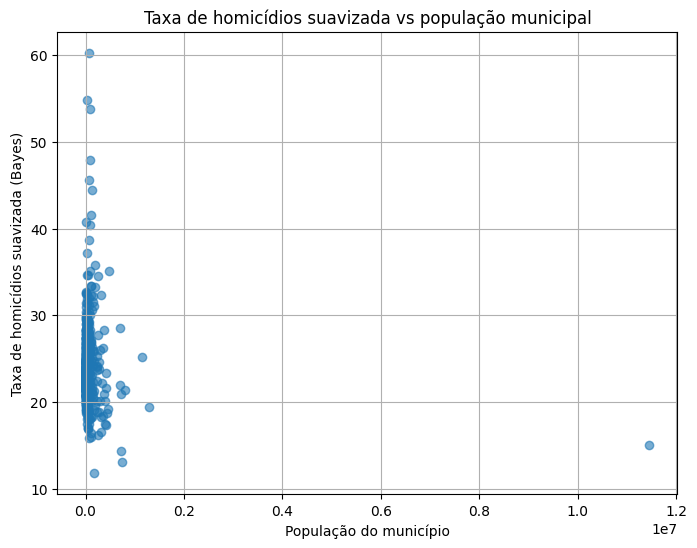

In [56]:
plt.figure(figsize=(8,6))

plt.scatter(
    df_tratado["resident_population"],
    df_tratado["tx_homicidios_bayes"],
    alpha=0.6
)

plt.xlabel("População do município")
plt.ylabel("Taxa de homicídios suavizada (Bayes)")

plt.title("Taxa de homicídios suavizada vs população municipal")

plt.grid(True)

plt.show()

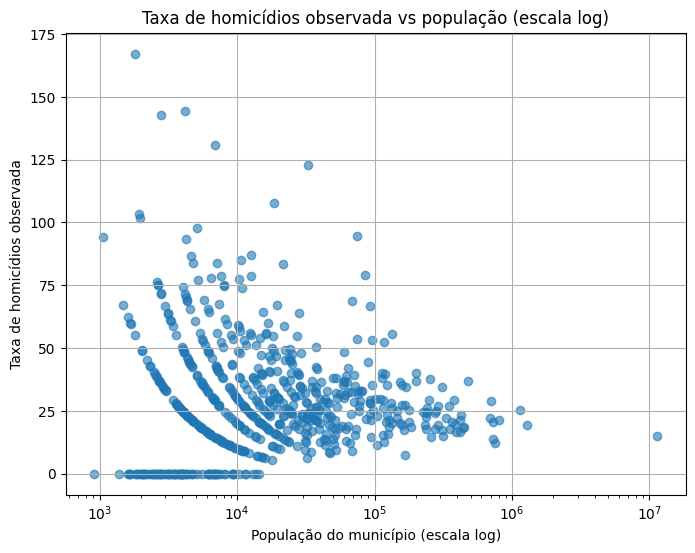

In [57]:
plt.figure(figsize=(8,6))

plt.scatter(
    df_tratado["resident_population"],
    df_tratado["tx_homicidios_observada"],
    alpha=0.6
)

plt.xscale("log")

plt.xlabel("População do município (escala log)")
plt.ylabel("Taxa de homicídios observada")

plt.title("Taxa de homicídios observada vs população (escala log)")

plt.grid(True)

plt.show()

In [58]:
taxa_media = df_tratado["tx_homicidios_observada"].mean()

In [59]:
import numpy as np

pop = df_tratado["resident_population"]

limite_superior = taxa_media + 1.96 * np.sqrt(taxa_media / pop * 100000)
limite_inferior = taxa_media - 1.96 * np.sqrt(taxa_media / pop * 100000)

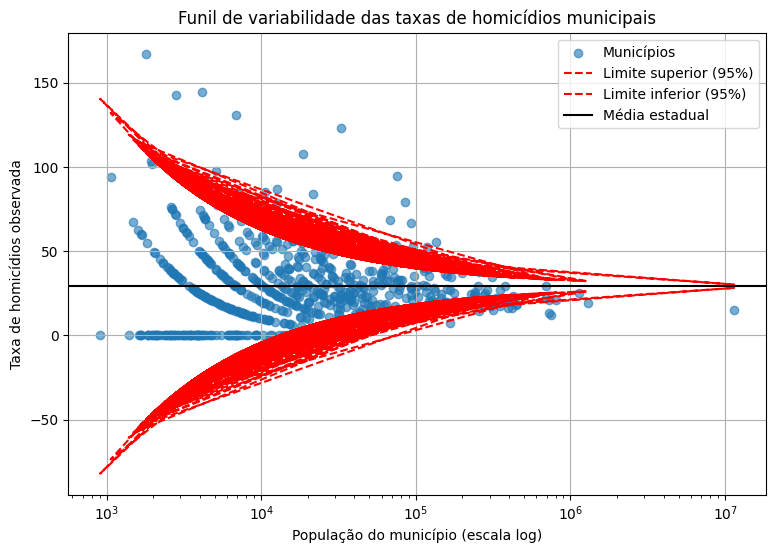

In [60]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9,6))

plt.scatter(
    df_tratado["resident_population"],
    df_tratado["tx_homicidios_observada"],
    alpha=0.6,
    label="Municípios"
)

plt.plot(
    df_tratado["resident_population"],
    limite_superior,
    color="red",
    linestyle="--",
    label="Limite superior (95%)"
)

plt.plot(
    df_tratado["resident_population"],
    limite_inferior,
    color="red",
    linestyle="--",
    label="Limite inferior (95%)"
)

plt.axhline(
    taxa_media,
    color="black",
    linestyle="-",
    label="Média estadual"
)

plt.xscale("log")

plt.xlabel("População do município (escala log)")
plt.ylabel("Taxa de homicídios observada")

plt.title("Funil de variabilidade das taxas de homicídios municipais")

plt.legend()

plt.grid(True)

plt.show()

In [145]:
import numpy as np

pop_seq = np.linspace(
    df_tratado["resident_population"].min(),
    df_tratado["resident_population"].max(),
    500
)

In [146]:
taxa_media = df_tratado["tx_homicidios_observada"].mean()

limite_sup = taxa_media + 1.96 * np.sqrt(taxa_media / pop_seq * 100000)
limite_inf = taxa_media - 1.96 * np.sqrt(taxa_media / pop_seq * 100000)
limite_inf = np.maximum(limite_inf, 0)

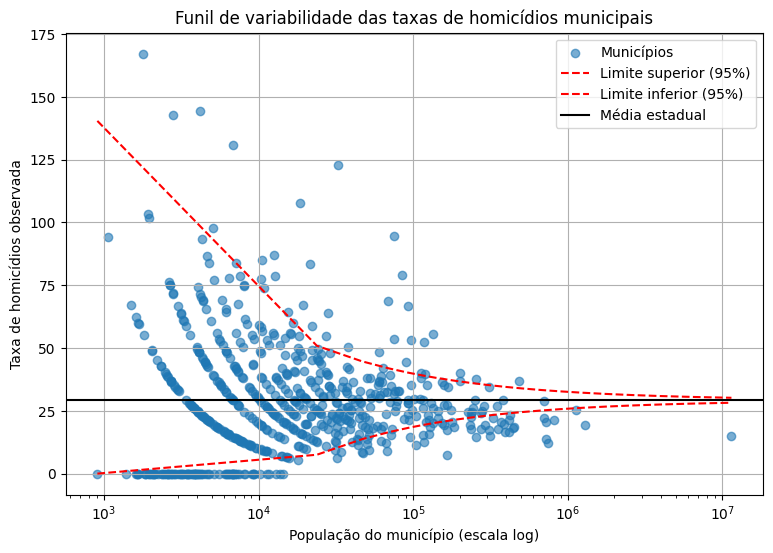

In [147]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9,6))

# pontos dos municípios
plt.scatter(
    df_tratado["resident_population"],
    df_tratado["tx_homicidios_observada"],
    alpha=0.6,
    label="Municípios"
)

# limites do funil
plt.plot(
    pop_seq,
    limite_sup,
    color="red",
    linestyle="--",
    label="Limite superior (95%)"
)

plt.plot(
    pop_seq,
    limite_inf,
    color="red",
    linestyle="--",
    label="Limite inferior (95%)"
)

# média estadual
plt.axhline(
    taxa_media,
    color="black",
    linestyle="-",
    label="Média estadual"
)

plt.xscale("log")

plt.xlabel("População do município (escala log)")
plt.ylabel("Taxa de homicídios observada")

plt.title("Funil de variabilidade das taxas de homicídios municipais")

plt.legend()
plt.grid(True)

plt.show()

In [148]:
df_cooks = pd.read_csv("outputs/tables/cooks_distance_base_completa.csv")
df_cooks.sort_values("cooks_distance", ascending=False).head(10)

FileNotFoundError: [Errno 2] No such file or directory: 'outputs/tables/cooks_distance_base_completa.csv'

In [143]:
df_cooks.describe().round(2)

NameError: name 'df_cooks' is not defined

In [142]:
df_cooks[df_cooks["codigo"] == 3550308]

NameError: name 'df_cooks' is not defined

In [141]:
from IPython.display import Image

Image("outputs/figures/feature_importance_base_completa.png")

FileNotFoundError: No such file or directory: 'outputs/figures/feature_importance_base_completa.png'

FileNotFoundError: No such file or directory: 'outputs/figures/feature_importance_base_completa.png'

<IPython.core.display.Image object>

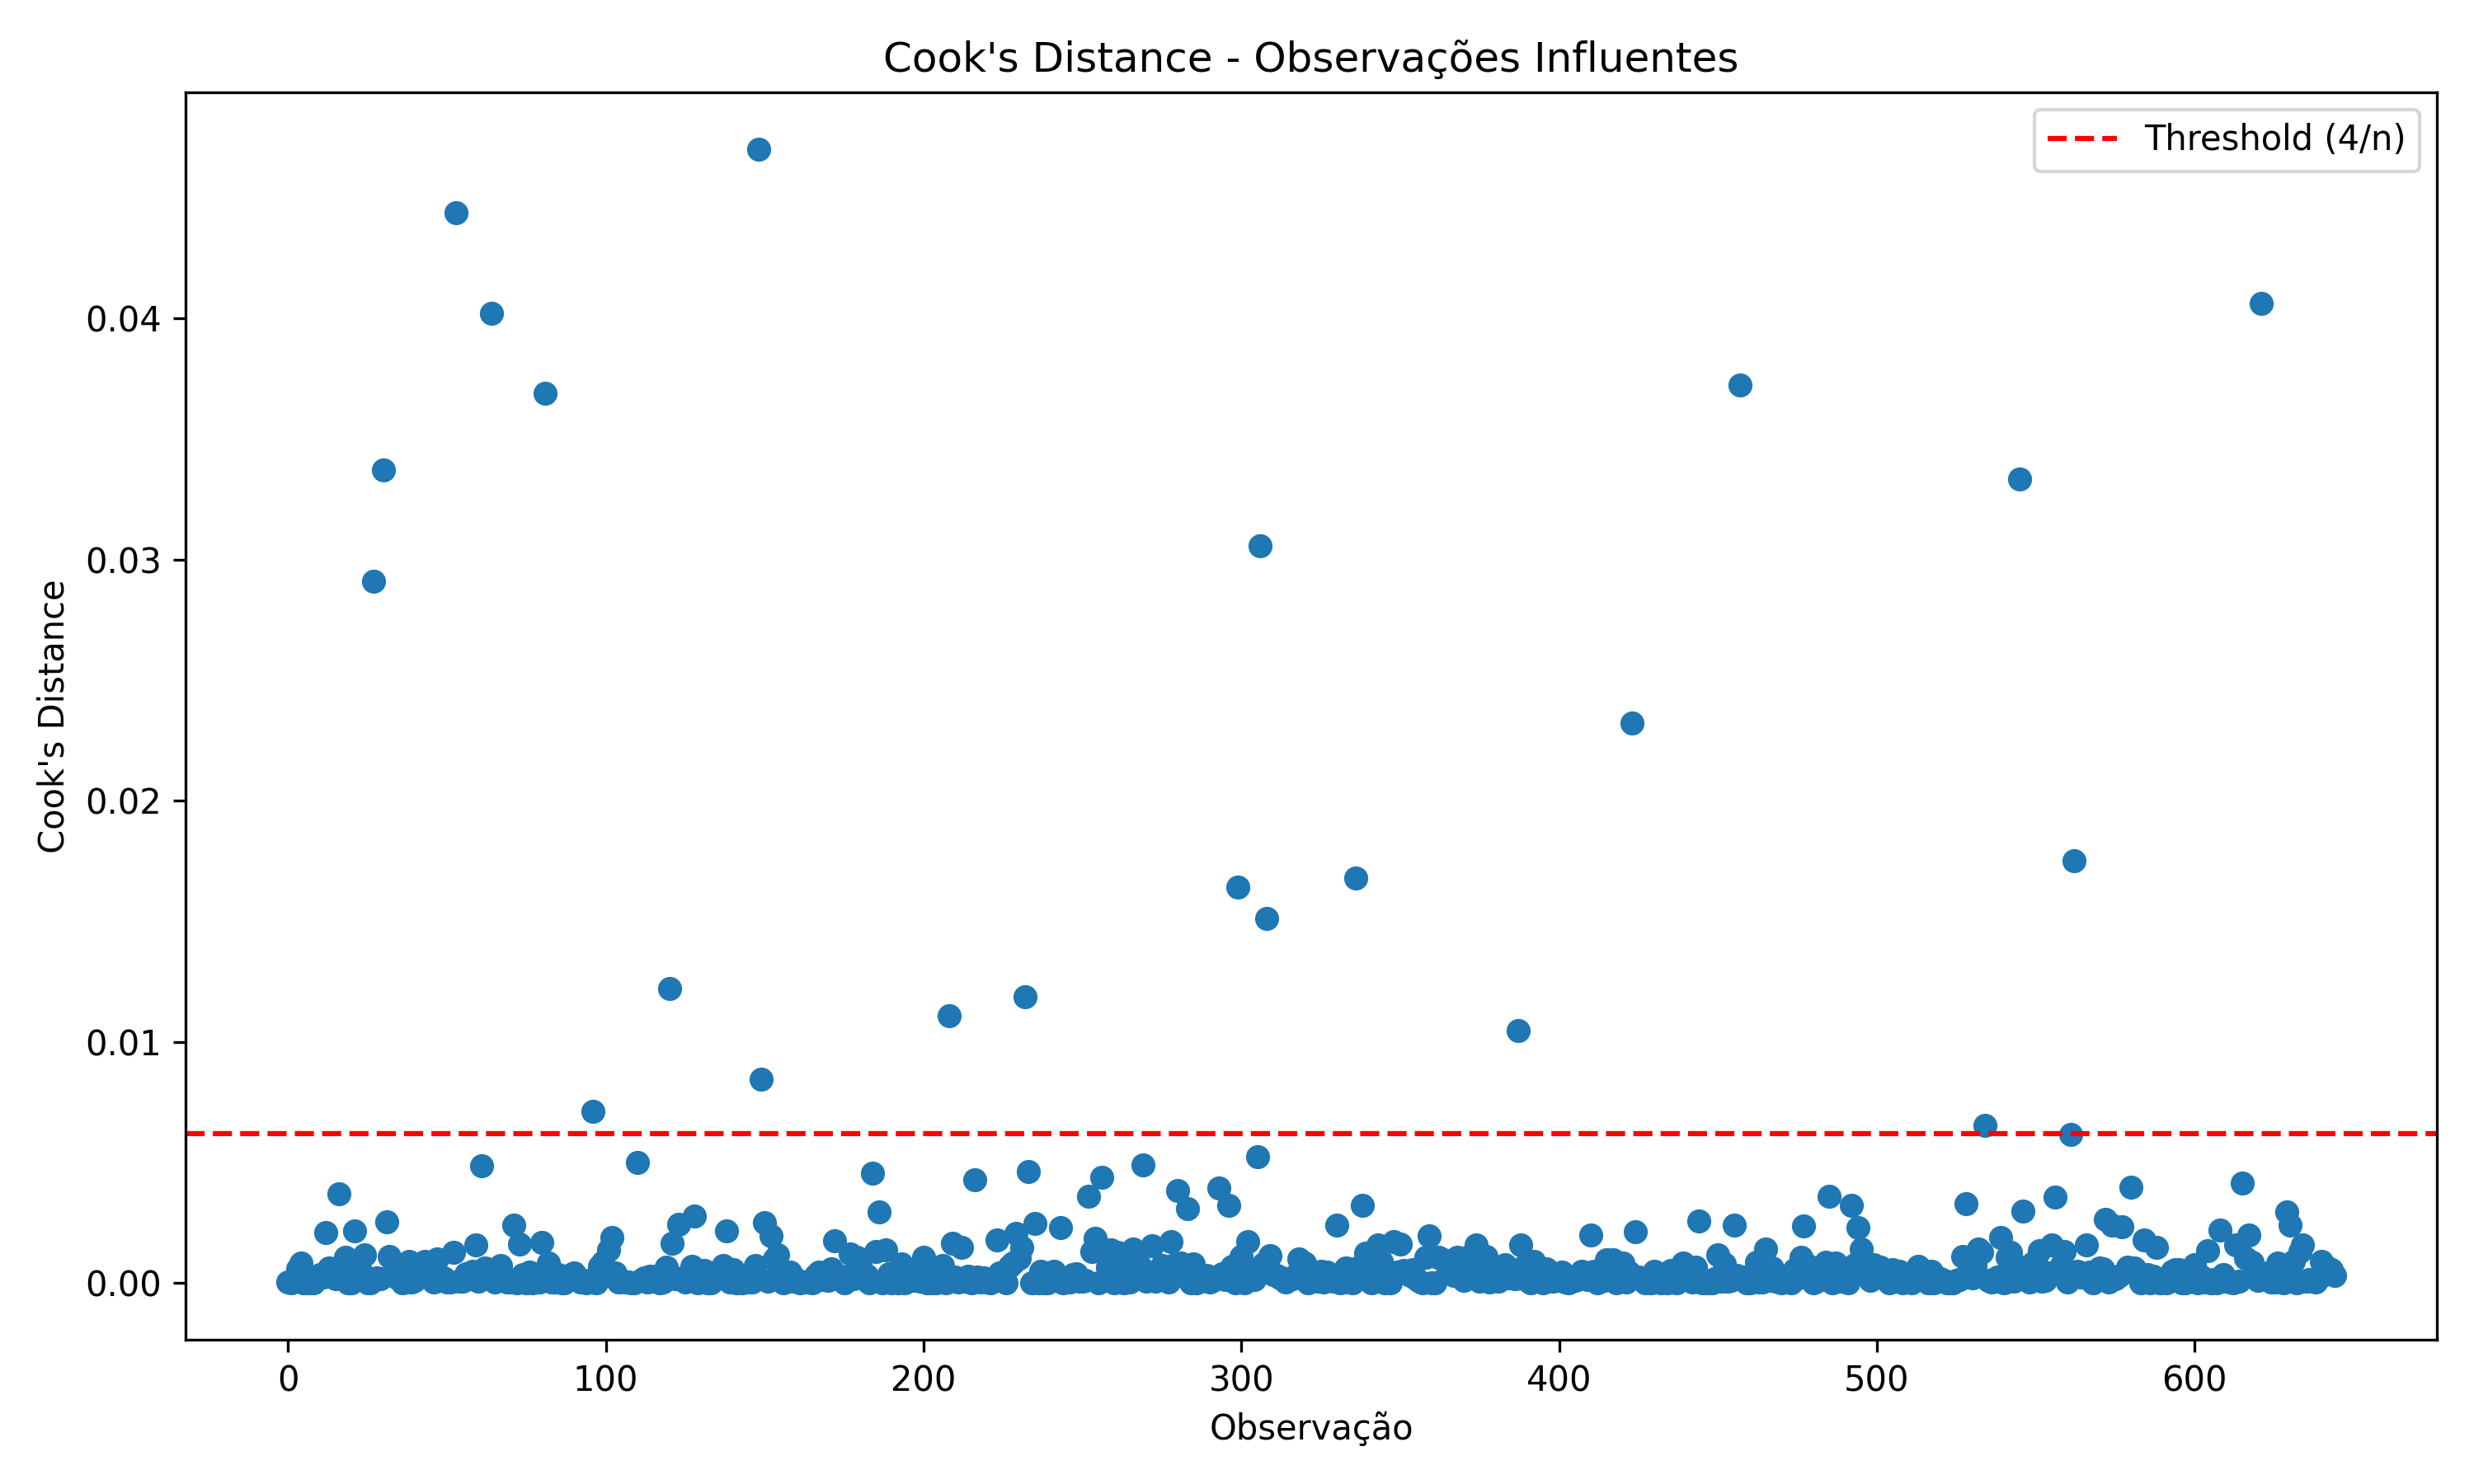

In [14]:
Image("outputs/figures/cooks_distance_base_completa.png")

In [15]:
df_results.round(3)

,Modelo,R2,RMSE,cenario
0,Regressão Linear,0.005,5.185,base_completa
1,Random Forest,0.126,4.857,base_completa
2,XGBoost,0.166,4.745,base_completa
3,Regressão Linear,0.003,5.205,sem_sao_paulo
4,Random Forest,0.114,4.908,sem_sao_paulo
5,XGBoost,-0.006,5.229,sem_sao_paulo
6,Regressão Linear,0.006,3.543,sem_influentes
7,Random Forest,-0.001,3.555,sem_influentes
8,XGBoost,-0.195,3.884,sem_influentes
9,Regressão Linear,0.009,0.173,log_taxa


In [22]:
df_results.to_excel("tabela_modelos.xlsx", index=False)

In [1]:
import geopandas as gpd

gdf = gpd.read_file("data/geodata/municipios_sp.geojson")

print(gdf.columns)

Index(['id', 'name', 'description', 'geometry'], dtype='object')


In [1]:
pip install libpysal esda

Note: you may need to restart the kernel to use updated packages.


You should consider upgrading via the 'c:\Users\jacki\Documents\OneDrive\Documents\USP\TCC\determinantes-criminalidade-sp\venv\Scripts\python.exe -m pip install --upgrade pip' command.


In [2]:
pip install shap

You should consider upgrading via the 'c:\Users\jacki\Documents\OneDrive\Documents\USP\TCC\determinantes-criminalidade-sp\venv\Scripts\python.exe -m pip install --upgrade pip' command.



     -------------------------------------- 547.2/547.2 KB 5.8 MB/s eta 0:00:00
     ---------------------------------------- 78.4/78.4 KB 4.3 MB/s eta 0:00:00
     ---------------------------------------- 2.7/2.7 MB 28.5 MB/s eta 0:00:00
     --------------------------------------- 28.1/28.1 MB 17.7 MB/s eta 0:00:00


In [3]:
import geopandas as gpd

gdf = gpd.read_file("data/geodata/municipios_sp.geojson")

gdf.iloc[232]

id                                                       3520400
name                                                    Ilhabela
description                                             Ilhabela
geometry       POLYGON ((-45.2951048852 -23.9174266396, -45.2...
Name: 232, dtype: object

In [15]:
df['per_cent_unemployed'].describe()

count       645
unique      588
top       76,76
freq          3
Name: per_cent_unemployed, dtype: object

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error
from xgboost import XGBRegressor
import statsmodels.api as sm
import pandas as pd
import numpy as np


def train_models(df, features, target):

    X = df[features]
    y = df[target]

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.3,
        random_state=42
    )

    # Random Forest
    rf = RandomForestRegressor(
        n_estimators=300,
        random_state=42
    )

    rf.fit(X_train, y_train)

    # XGBoost
    xgb_model = XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=4,
        random_state=42
    )

    xgb_model.fit(X_train, y_train)

    # Regressão Linear
    X_train_const = sm.add_constant(X_train)

    ols = sm.OLS(y_train, X_train_const).fit()

    return rf, xgb_model, ols, X_test, y_test


def evaluate_models(rf, xgb_model, ols, X_test, y_test):

    pred_rf = rf.predict(X_test)
    pred_xgb = xgb_model.predict(X_test)

    X_test_const = sm.add_constant(X_test)

    pred_ols = ols.predict(X_test_const)

    results = pd.DataFrame({

        "modelo": [
            "Regressão Linear",
            "Random Forest",
            "XGBoost"
        ],

        "R2": [
            r2_score(y_test, pred_ols),
            r2_score(y_test, pred_rf),
            r2_score(y_test, pred_xgb)
        ],

        "RMSE": [
            np.sqrt(mean_squared_error(y_test, pred_ols)),
            np.sqrt(mean_squared_error(y_test, pred_rf)),
            np.sqrt(mean_squared_error(y_test, pred_xgb))
        ]

    })

    return results

In [22]:
import numpy as np
def generate_scenarios(df):

    cenarios = {}

    cenarios["base_completa"] = df.copy()

    cenarios["sem_sao_paulo"] = df[df["codigo"] != 3550308]

    threshold = 4 / len(df)

    cenarios["sem_influentes"] = df[df["cooks_distance"] < threshold]

    df_log = df.copy()

    df_log["log_taxa"] = np.log1p(df_log["tx_homicidios_bayes"])

    df_log["log_populacao"] = np.log1p(df_log["resident_population"])

    df_log["log_pib"] = np.log1p(df_log["gdp_per_capita"])

    cenarios["modelo_log"] = df_log

    return cenarios

In [28]:

cenarios = generate_scenarios(df)

resultados_finais = []

rf_base = None
xgb_base = None
features_plot = None

KeyError: 'cooks_distance'

In [152]:
import shap
import matplotlib.pyplot as plt


def shap_analysis(model, X, output_path):

    explainer = shap.TreeExplainer(model)

    shap_values = explainer.shap_values(X)

    plt.figure()

    shap.summary_plot(
        shap_values,
        X,
        show=False
    )

    plt.title(
    "Impacto das variáveis na predição das taxas de homicídio municipais (XGBoost – SHAP)",
    fontsize=12
    )  

    plt.xlabel(
    "Valor SHAP (impacto na taxa prevista de homicídios – escala log)"
    )

    plt.tight_layout()
    
    plt.savefig(output_path)

    plt.close()

In [ ]:
Image("outputs/figures/cooks_distance_base_completa.png")